In [3]:
import seaborn as sns
import sklearn as skl
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
titanic = sns.load_dataset("titanic")

In [5]:
titanic.head()
titanic.info()
features=["pclass","sex","fare","age","embarked"]
target=["survived"]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
# MISSING DATA
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
# encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])

titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [9]:
x=titanic[features]
y=titanic[target]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42)


from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred=model.predict(x_test)

In [11]:
# evaluate
from sklearn.metrics import accuracy_score

print("accuracy_score",accuracy_score(y_test,y_pred))

accuracy_score 0.7686567164179104


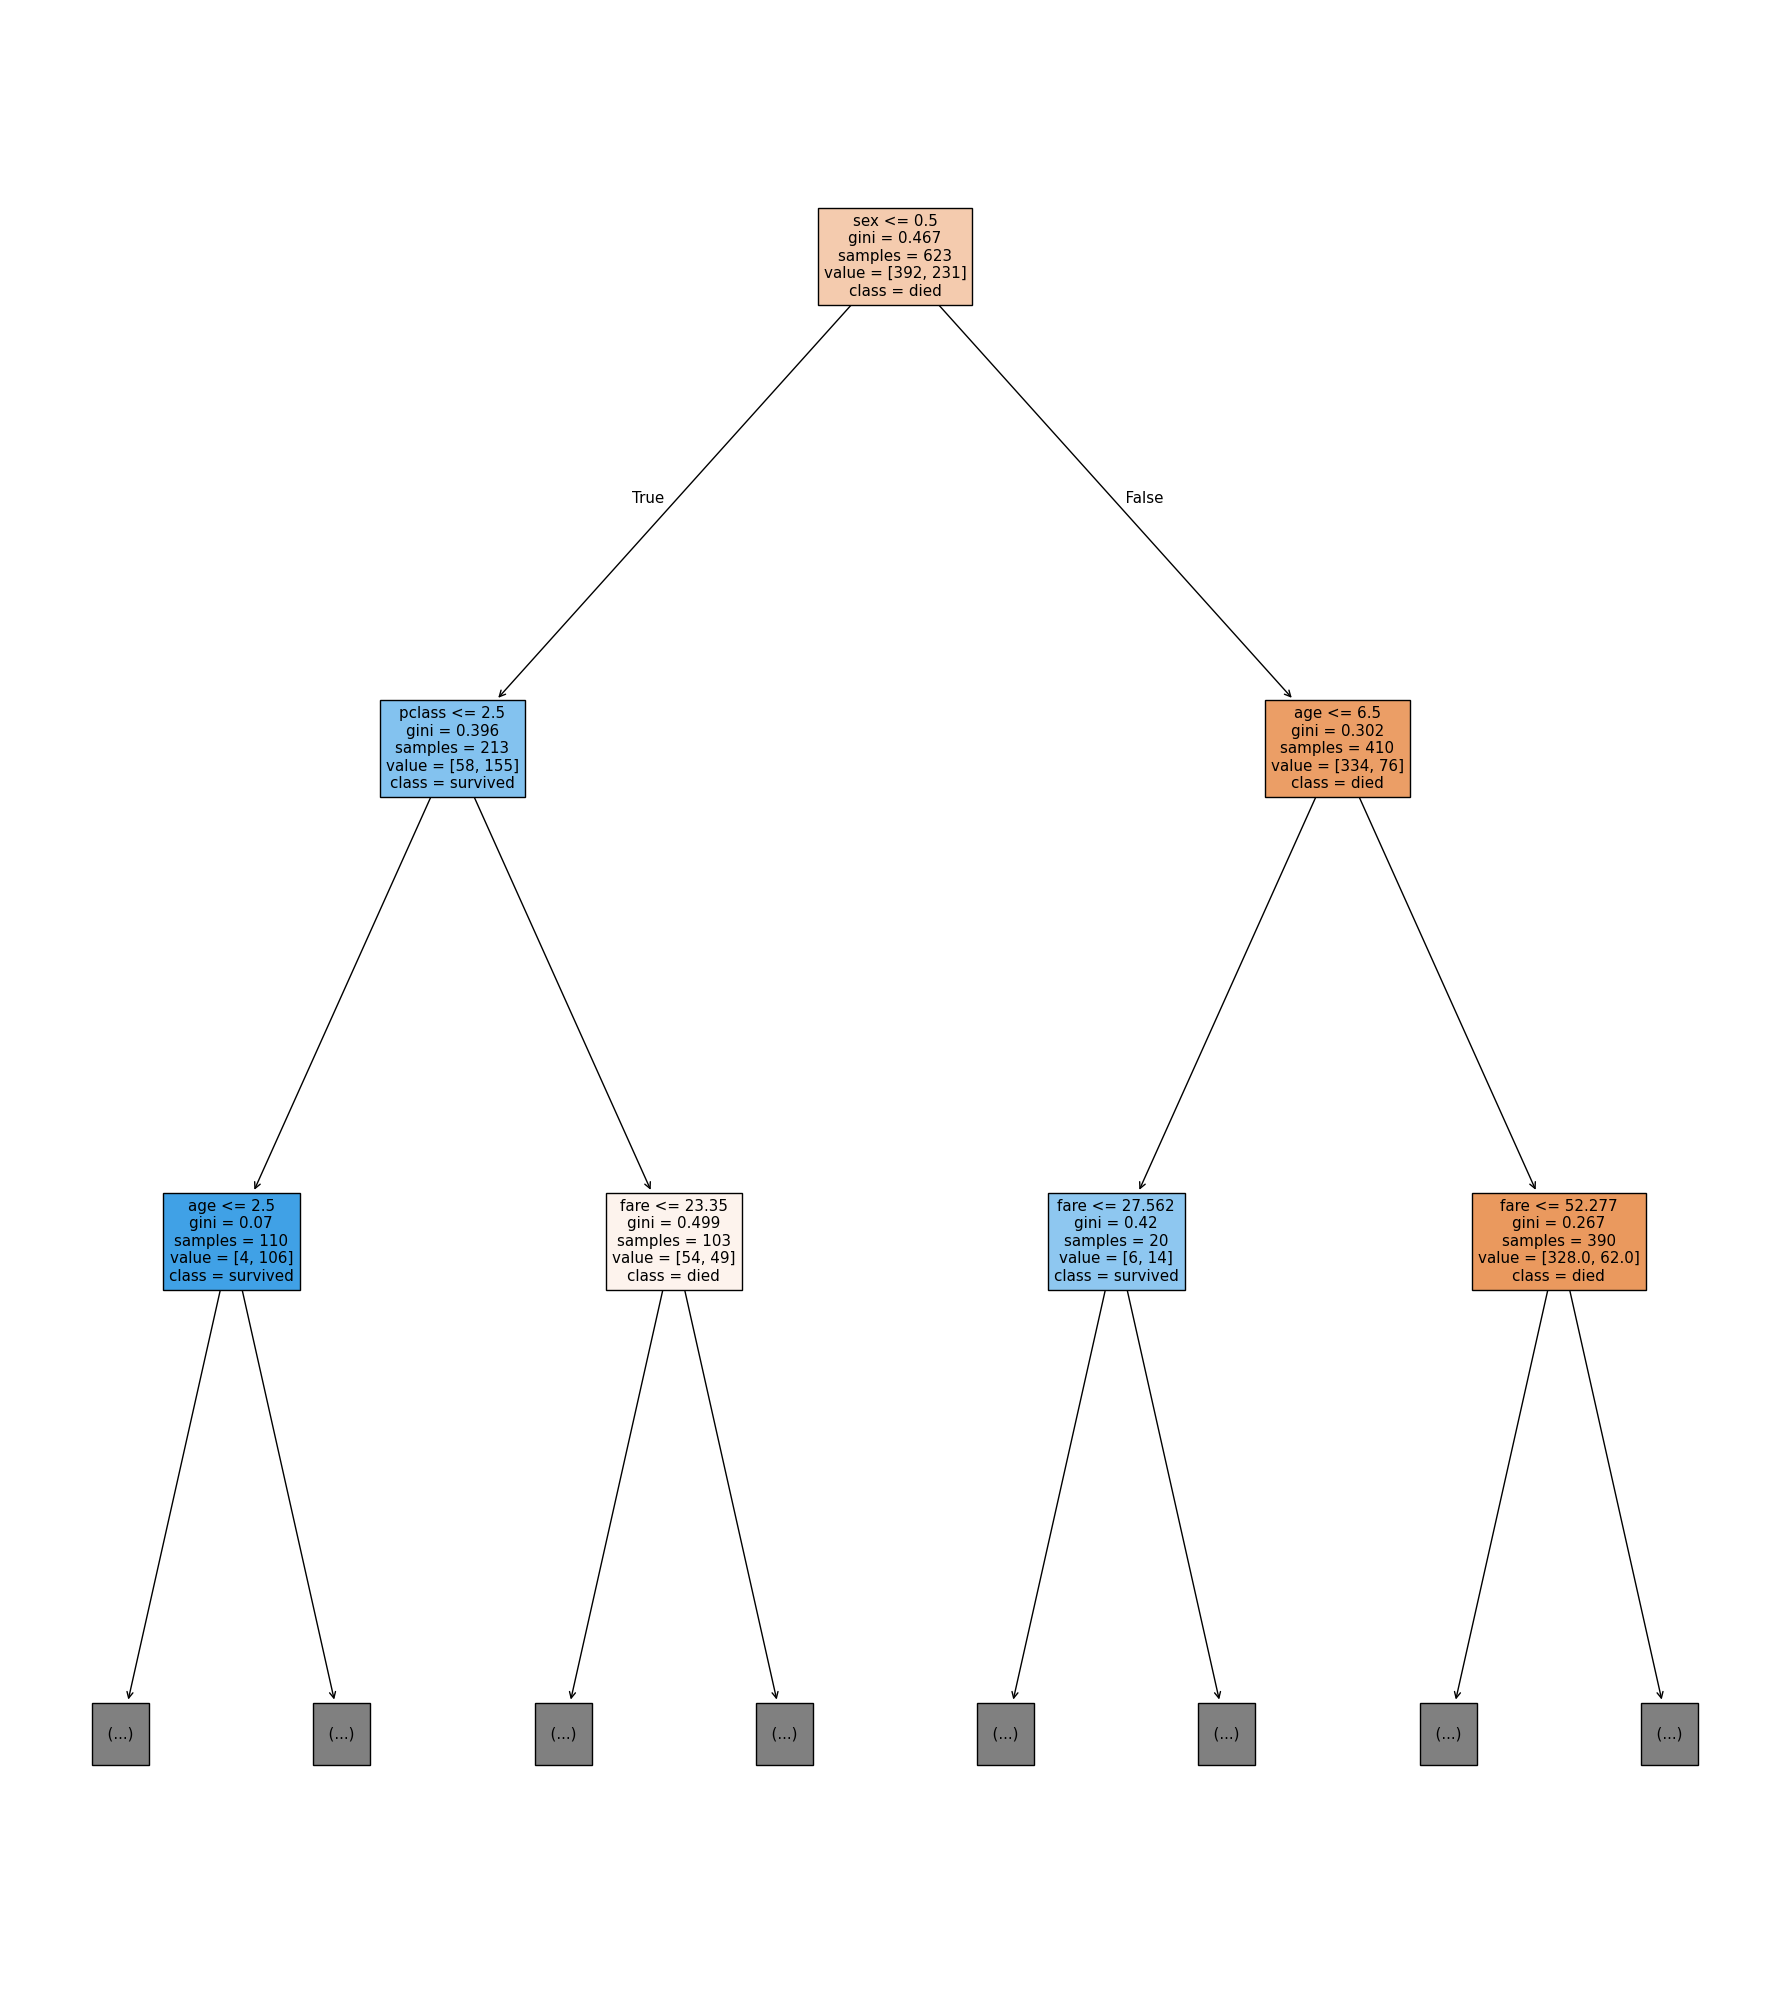

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()



In [13]:
# decision tree with pre _pruning

In [14]:
max_depths=[1,2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

#max_dept =4 have high accu
   

for depth=1, accuracy=0.7910447761194029
for depth=2, accuracy=0.7723880597014925
for depth=3, accuracy=0.8059701492537313
for depth=4, accuracy=0.8246268656716418
for depth=5, accuracy=0.7985074626865671
for depth=6, accuracy=0.7835820895522388
for depth=7, accuracy=0.7798507462686567
for depth=8, accuracy=0.7947761194029851
for depth=9, accuracy=0.7686567164179104
for depth=10, accuracy=0.7873134328358209


In [15]:
min_sample_splits=[5,10,15,20,25,30]
for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for depth={split}, accuracy={acc}")


for depth=5, accuracy=0.8246268656716418
for depth=10, accuracy=0.8246268656716418
for depth=15, accuracy=0.8171641791044776
for depth=20, accuracy=0.8171641791044776
for depth=25, accuracy=0.8208955223880597
for depth=30, accuracy=0.8208955223880597


# post pruning

In [16]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
path = full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00133761 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145
 0.00150482 0.00151596 0.00152184 0.00167202 0.00171215 0.00183444
 0.0019012  0.00195674 0.00214018 0.00233474 0.0024077  0.00260835
 0.00263292 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625
 0.00302412 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248
 0.01236198 0.01787674 0.04065074 0.1323581 ]


In [18]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train, y_train)

    trees.append((model, alpha))

In [19]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(x_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [20]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


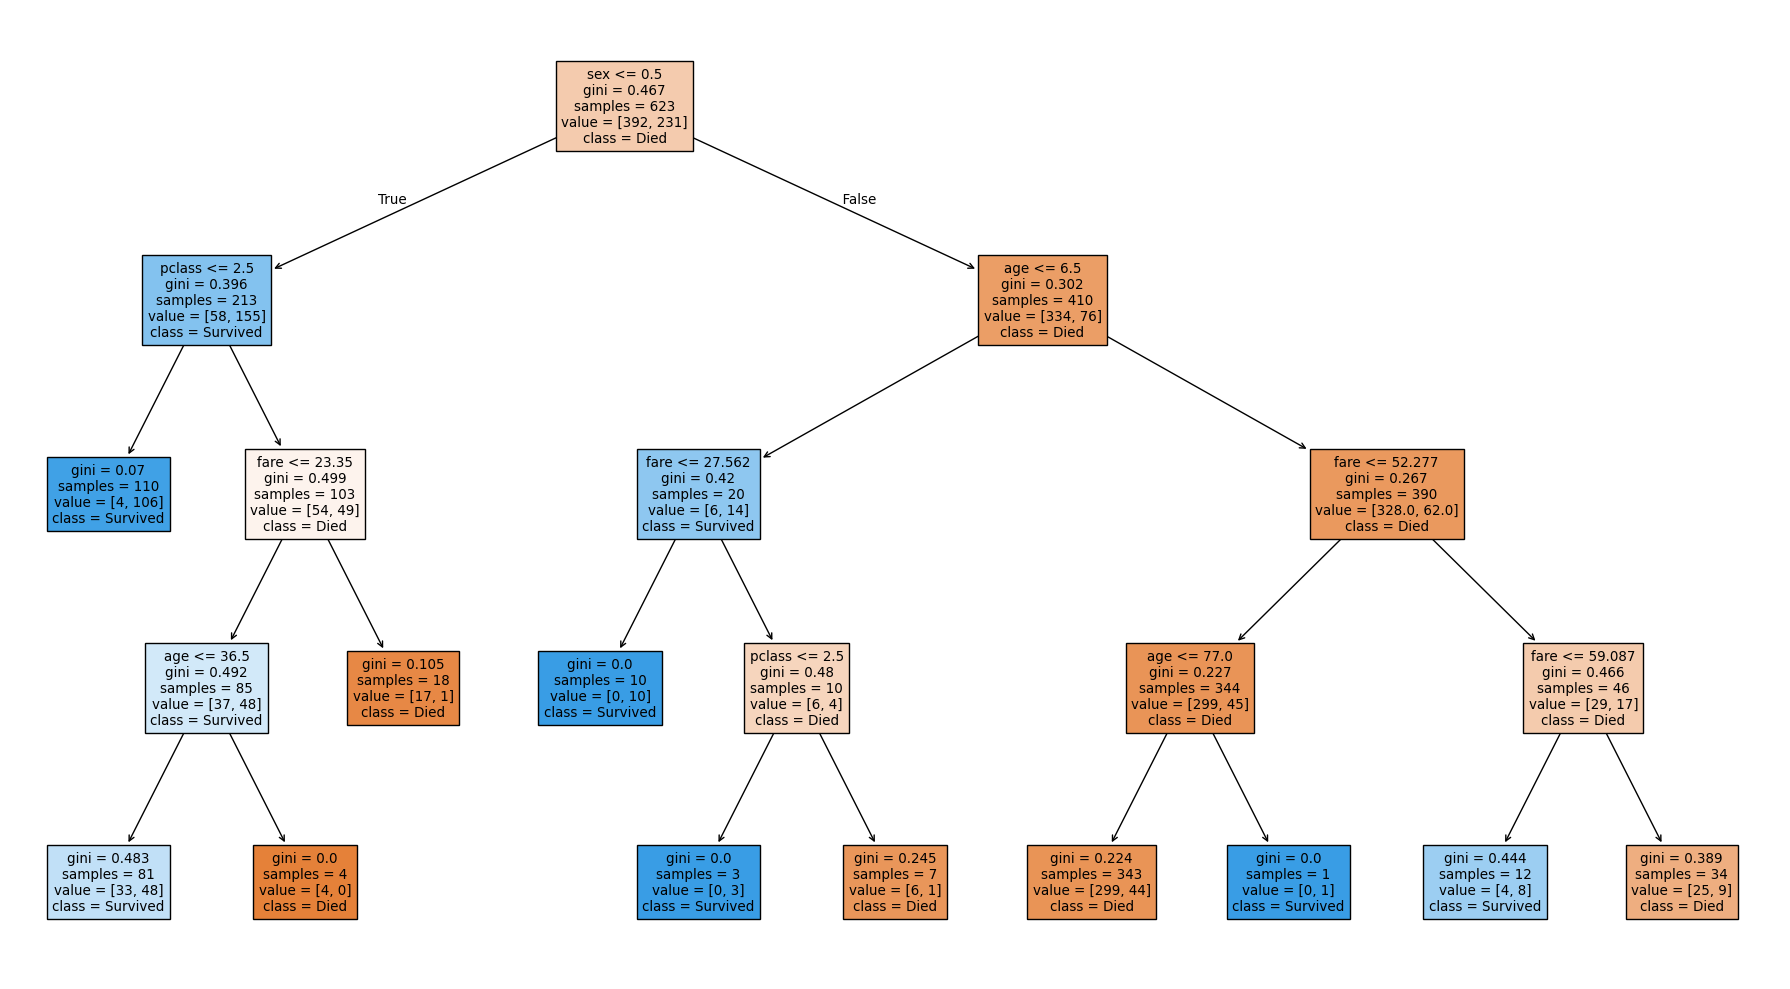

In [21]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)
        
plt.tight_layout()
plt.show()

In [22]:
print(best_model.score(x_test, y_test))

0.8246268656716418


In [23]:
best_alpha

np.float64(0.0017121455323702516)

In [27]:
from sklearn.datasets import load_diabetes

In [28]:
df=load_diabetes(as_frame=True).frame

In [32]:
x=df.drop("target",axis=1)
y=df["target"]

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)


In [34]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
y_pred=model.predict(x_test)

In [39]:
from sklearn.metrics import r2_score,mean_squared_error


In [41]:
print("r2_score",r2_score(y_test,y_pred))

r2_score -0.14049691585658586


In [42]:
from sklearn.tree import plot_tree

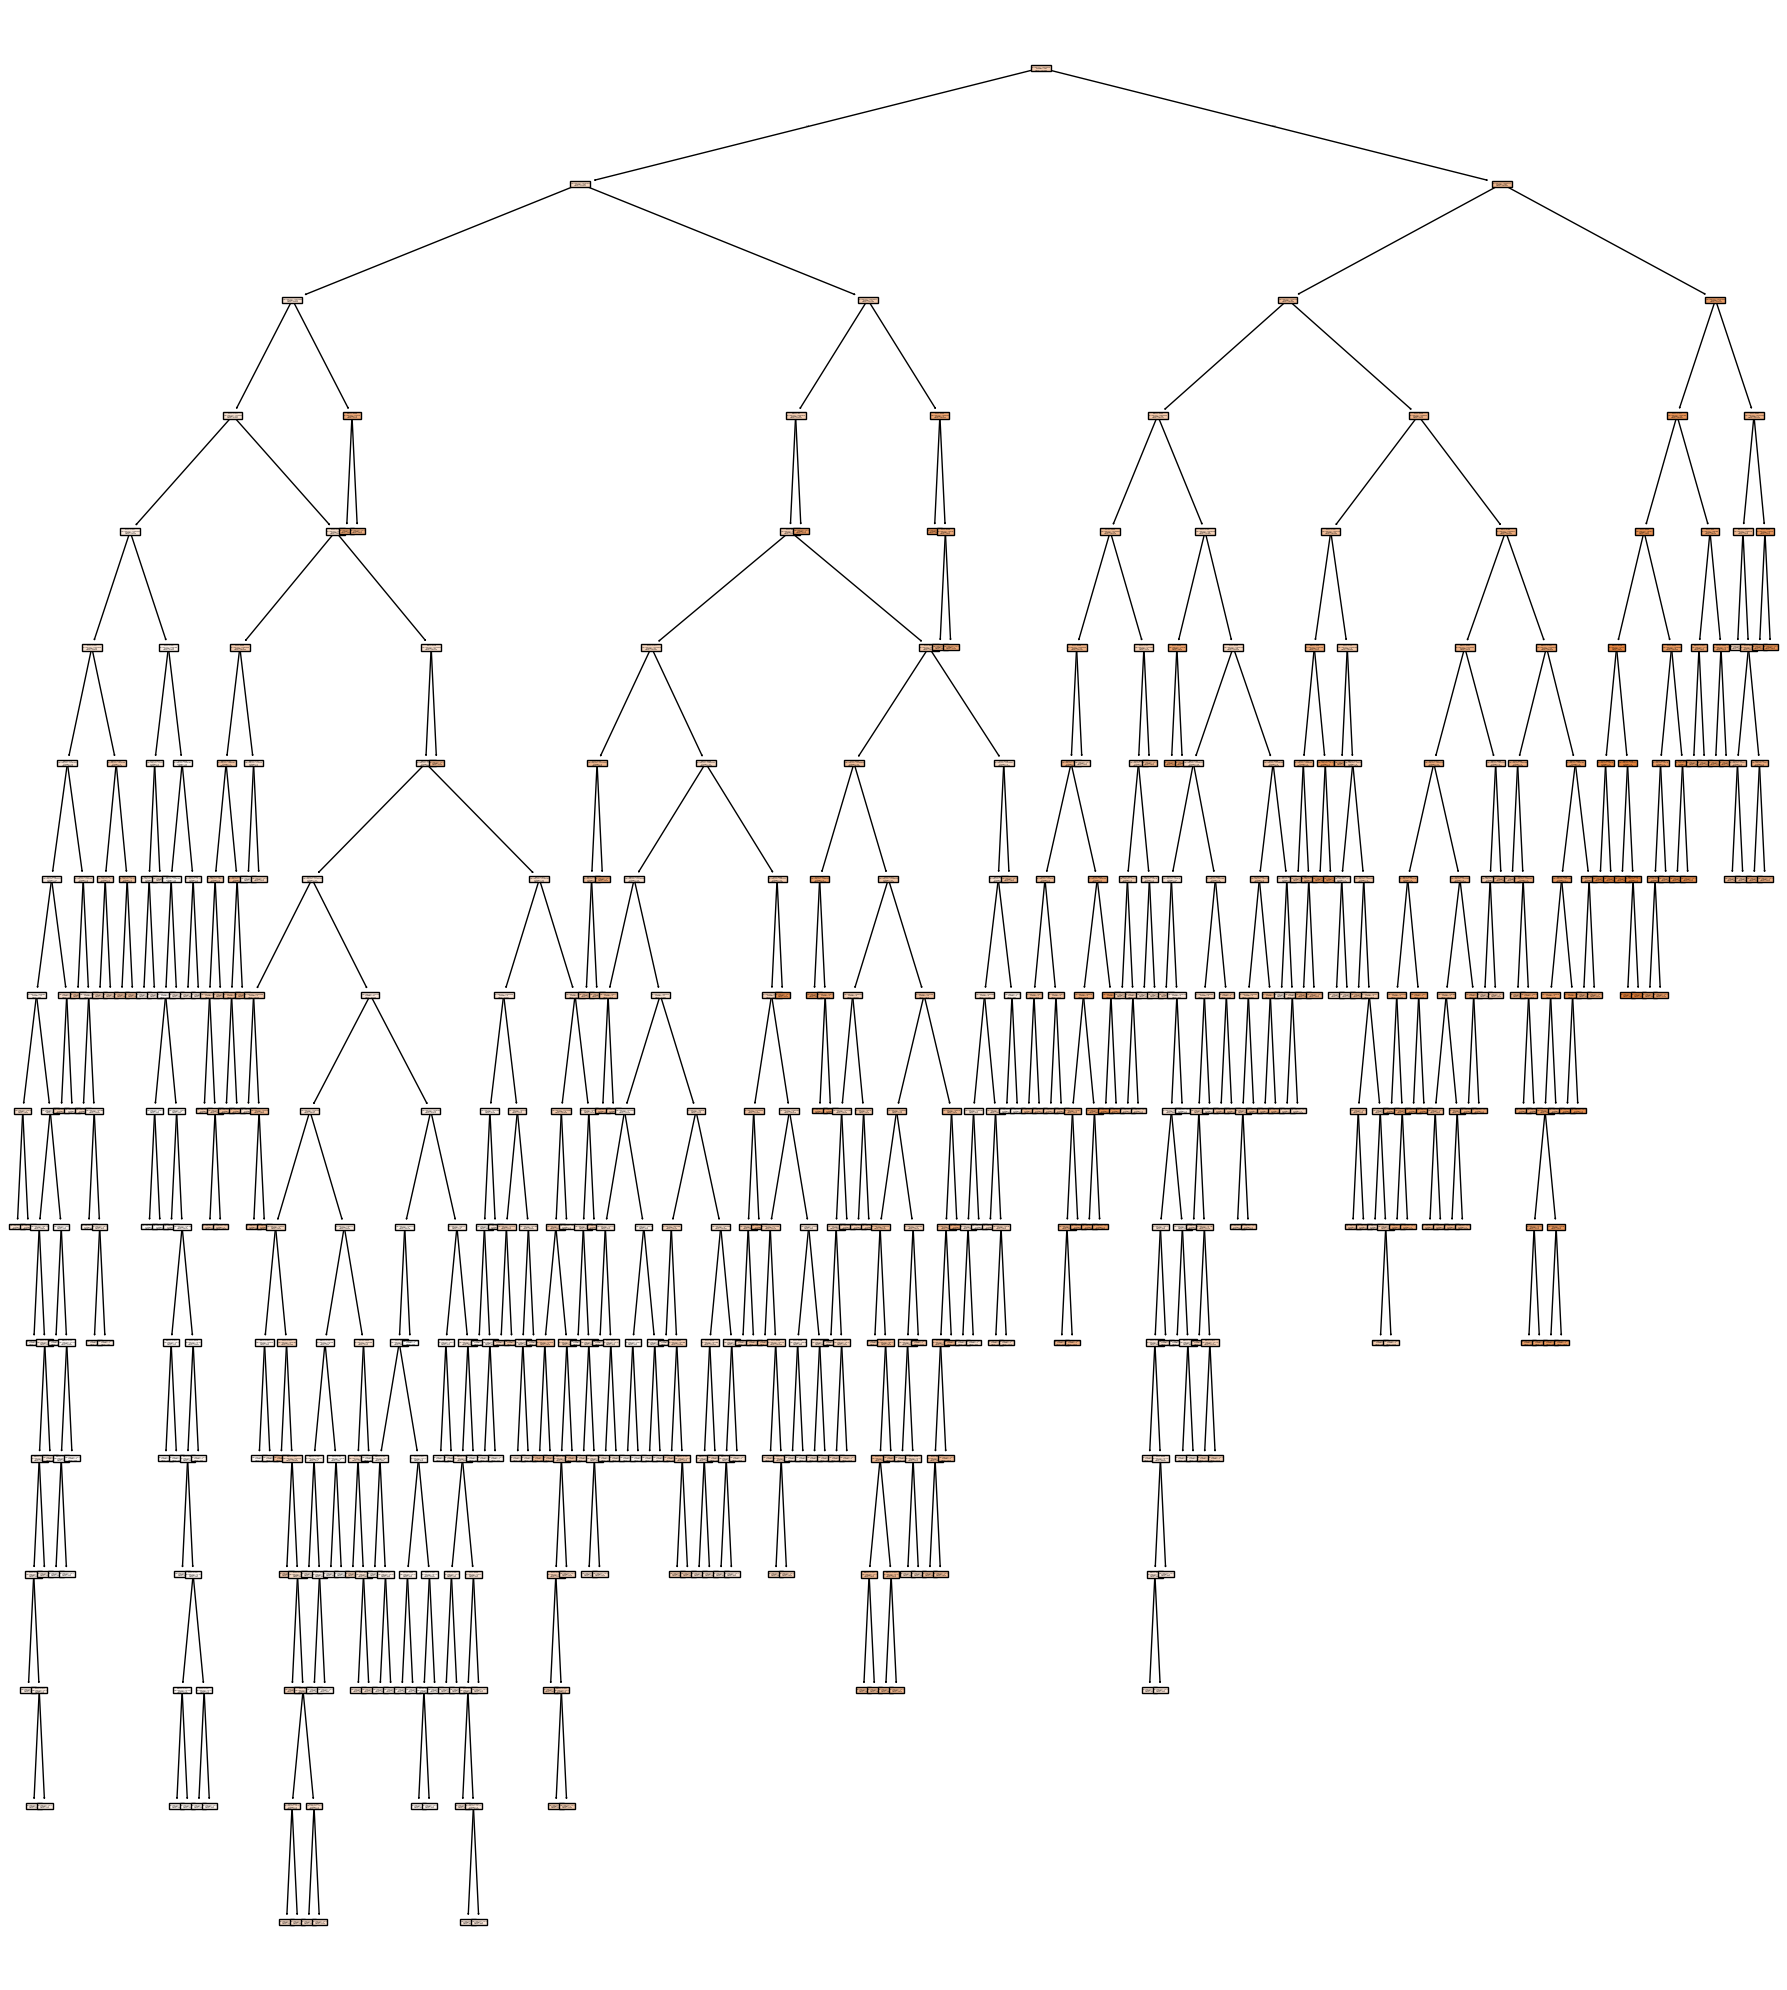

In [44]:
plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True
)
plt.tight_layout()
plt.show()